<a href="https://colab.research.google.com/github/Devadeth-cmyk/vehicle-damage-insurance-ai/blob/main/test_fusion_pipeline_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics opencv-python-headless -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 728.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 7.7 MB/s eta 0:00:00


In [3]:
import sys, os

PROJECT_ROOT = '/content/drive/MyDrive/AI ML/Projects'
INFERENCE_DIR = f'{PROJECT_ROOT}/inference'
sys.path.insert(0, INFERENCE_DIR)

required_files = [
    'damage_detector.py', 'parts_detector.py', 'fusion.py',
    'claim_analyzer.py', 'visualize.py', 'severity_estimator.py', 'severity_detector.py',
]
for fname in required_files:
    path = os.path.join(INFERENCE_DIR, fname)
    print(f'{fname}: {"FOUND" if os.path.exists(path) else "MISSING - upload it to " + INFERENCE_DIR}')

damage_detector.py: FOUND
parts_detector.py: FOUND
fusion.py: FOUND
claim_analyzer.py: FOUND
visualize.py: FOUND
severity_estimator.py: FOUND
severity_detector.py: FOUND


## Set Model Paths



In [4]:
DAMAGE_MODEL_PATH = f'{PROJECT_ROOT}/models/damage/best.pt'
PARTS_MODEL_PATH = f'{PROJECT_ROOT}/models/parts/parts.pt'
SEVERITY_MODEL_PATH = f'{PROJECT_ROOT}/models/severity/best.pt'

print('Damage model exists:', os.path.exists(DAMAGE_MODEL_PATH))
print('Parts model exists:', os.path.exists(PARTS_MODEL_PATH))
print('Severity model exists:', os.path.exists(SEVERITY_MODEL_PATH))

Damage model exists: True
Parts model exists: True
Severity model exists: True


## Load the Claim Analyzer

In [5]:
from claim_analyzer import ClaimAnalyzer

analyzer = ClaimAnalyzer(
    DAMAGE_MODEL_PATH,
    PARTS_MODEL_PATH,
    severity_model_path=SEVERITY_MODEL_PATH if os.path.exists(SEVERITY_MODEL_PATH) else None,
)
print('Damage model classes:', analyzer.damage_detector.model.names)
print('Parts model classes:', analyzer.parts_detector.model.names)
print('Severity model active:', analyzer.severity_detector is not None)
if analyzer.severity_detector is not None:
    print('Severity model classes:', analyzer.severity_detector.model.names)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Damage model classes: {0: 'dent', 1: 'scratch', 2: 'crack', 3: 'glass shatter', 4: 'lamp broken', 5: 'tire flat'}
Parts model classes: {0: 'back_bumper', 1: 'back_door', 2: 'back_glass', 3: 'back_left_door', 4: 'back_left_light', 5: 'back_light', 6: 'back_right_door', 7: 'back_right_light', 8: 'front_bumper', 9: 'front_door', 10: 'front_glass', 11: 'front_left_door', 12: 'front_left_light', 13: 'front_light', 14: 'front_right_door', 15: 'front_right_light', 16: 'hood', 17: 'left_mirror', 18: 'object', 19: 'right_mirror', 20: 'tailgate', 21: 'trunk', 22: 'wheel'}
Severity model active: True
Severity model classes: {0: 'minor', 1: 'moderate', 2: 'severe'}


## Upload a Test Image

In [11]:
from google.colab import files

uploaded = files.upload()
test_image_path = list(uploaded.keys())[0]
print('Uploaded:', test_image_path)

Saving scratch.webp to scratch.webp
Uploaded: scratch.webp


## Run the Full Fusion Pipeline on One Image

In [12]:
import json

result = analyzer.analyze_image(test_image_path)
print(json.dumps(result, indent=2))

{
  "image": "scratch.webp",
  "status": "completed",
  "detections": [
    {
      "part": "front_bumper",
      "damage_type": "scratch",
      "severity": "Moderate",
      "severity_source": "model",
      "damage_confidence": 0.938,
      "part_confidence": 0.667,
      "overlap_score": 0.793,
      "bbox": [
        115.3,
        108.8,
        340.1,
        227.0
      ],
      "requires_review": false
    },
    {
      "part": "unknown",
      "damage_type": "dent",
      "severity": "Moderate",
      "severity_source": "heuristic",
      "damage_confidence": 0.525,
      "part_confidence": null,
      "overlap_score": 0.01,
      "bbox": [
        87.5,
        49.4,
        143.4,
        101.9
      ],
      "requires_review": true,
      "review_reason": "no_part_matched"
    },
    {
      "part": "front_bumper",
      "damage_type": "crack",
      "severity": "Moderate",
      "severity_source": "heuristic",
      "damage_confidence": 0.517,
      "part_confidence": 0.

## Check Severity Source Breakdown



In [13]:
from collections import Counter

sources = Counter(d.get('severity_source') for d in result['detections'])
print('Severity source breakdown for this image:', dict(sources))

Severity source breakdown for this image: {'model': 1, 'heuristic': 2}


## Generate Annotated Image

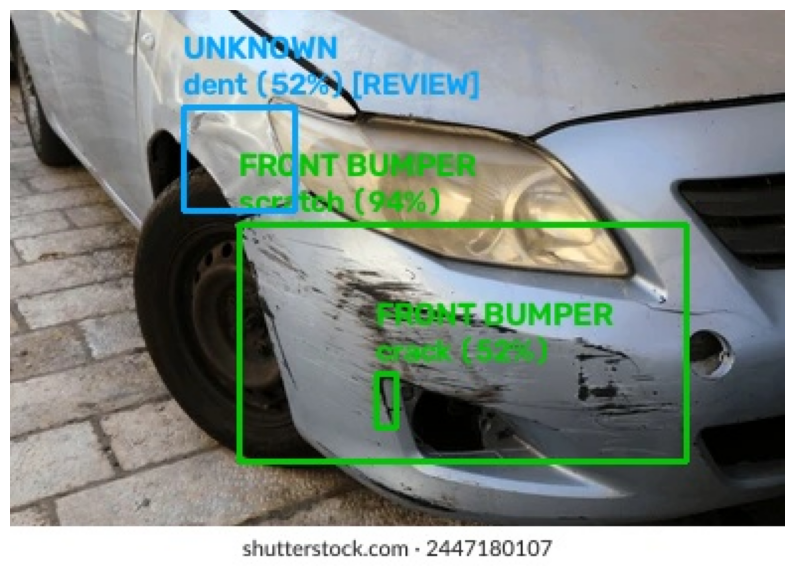

In [14]:
from visualize import annotate_image
import matplotlib.pyplot as plt
import cv2

output_path = 'annotated_result.jpg'
annotate_image(test_image_path, result['detections'], output_path)

img = cv2.cvtColor(cv2.imread(output_path), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

## Test Multi-Image Claim Processing

In [15]:
claim_result = analyzer.analyze_claim(claim_id='CLM-2026-00125', image_paths=[test_image_path])
print(json.dumps(claim_result, indent=2))

{
  "claim_id": "CLM-2026-00125",
  "damage_model_version": "cardd-v1",
  "parts_model_version": "parts-v1",
  "images": [
    {
      "image": "scratch.webp",
      "status": "completed",
      "detections": [
        {
          "part": "front_bumper",
          "damage_type": "scratch",
          "severity": "Moderate",
          "severity_source": "model",
          "damage_confidence": 0.938,
          "part_confidence": 0.667,
          "overlap_score": 0.793,
          "bbox": [
            115.3,
            108.8,
            340.1,
            227.0
          ],
          "requires_review": false
        },
        {
          "part": "unknown",
          "damage_type": "dent",
          "severity": "Moderate",
          "severity_source": "heuristic",
          "damage_confidence": 0.525,
          "part_confidence": null,
          "overlap_score": 0.01,
          "bbox": [
            87.5,
            49.4,
            143.4,
            101.9
          ],
          "requ